# Raceline Experiments

Turn the SLAM map into a centerline + track widths, then into a raceline.

**Pipeline:** `track_clean.pgm` -> driving surface -> skeleton -> ordered loop ->
smoothed spline -> per-point track widths -> CSV for a raceline optimizer.

**Kernel:** select `.venv-rl` (Python 3.10). Needs `numpy scipy matplotlib pyyaml scikit-image`.

The output CSV uses the column layout TUM's
[`global_racetrajectory_optimization`](https://github.com/TUMFTM/global_racetrajectory_optimization)
expects: `x_m, y_m, w_tr_right_m, w_tr_left_m`.

In [2]:
from pathlib import Path

import numpy as np
import yaml
from scipy import ndimage, interpolate
from skimage.morphology import skeletonize
import matplotlib.pyplot as plt

MAP = Path.home() / "Documents/roboracer/devkit_ws/src/racer_mapping/maps/track_clean"
OUT = Path.home() / "Documents/roboracer/raceline"
OUT.mkdir(exist_ok=True)

# Published competition spec: width 0.270 m, wheelbase 0.324 m, track 0.236 m.
# The optimizer needs this to keep the car inside the walls.
VEHICLE_WIDTH = 0.27
N_POINTS = 400        # centerline samples around the lap
SPLINE_SMOOTH = 0.5   # scipy splprep `s`; higher = smoother, less faithful

## 1. Load the map

In [3]:
meta = yaml.safe_load(open(MAP.with_suffix(".yaml")))
res = meta["resolution"]
ox, oy, _ = meta["origin"]

with open(MAP.with_suffix(".pgm"), "rb") as f:
    assert f.readline().strip() == b"P5"
    line = f.readline()
    while line.startswith(b"#"):
        line = f.readline()
    W, H = map(int, line.split())
    f.readline()
    img = np.frombuffer(f.read(W * H), dtype=np.uint8).reshape(H, W)

# PGM row 0 is the TOP of the image, which is MAX y in world coordinates.
def px2world(r, c):
    return ox + (c + 0.5) * res, oy + (H - r - 0.5) * res

def world2px(x, y):
    return H - (y - oy) / res - 0.5, (x - ox) / res - 0.5

WALL, UNKNOWN, FREE = img == 0, img == 205, img >= 254
EXTENT = [ox, ox + W * res, oy, oy + H * res]

print(f"{W} x {H} cells @ {res} m  =  {W*res:.1f} x {H*res:.1f} m")
print(f"origin {ox}, {oy}")
print(f"wall {WALL.sum()}   free {FREE.sum()}   unknown {UNKNOWN.sum()}")
assert set(np.unique(img)) <= {0, 205, 254}, "unexpected pixel values -- anti-aliasing?"

108 x 316 cells @ 0.05 m  =  5.4 x 15.8 m
origin -3.71, -8.61
wall 3425   free 18935   unknown 11768


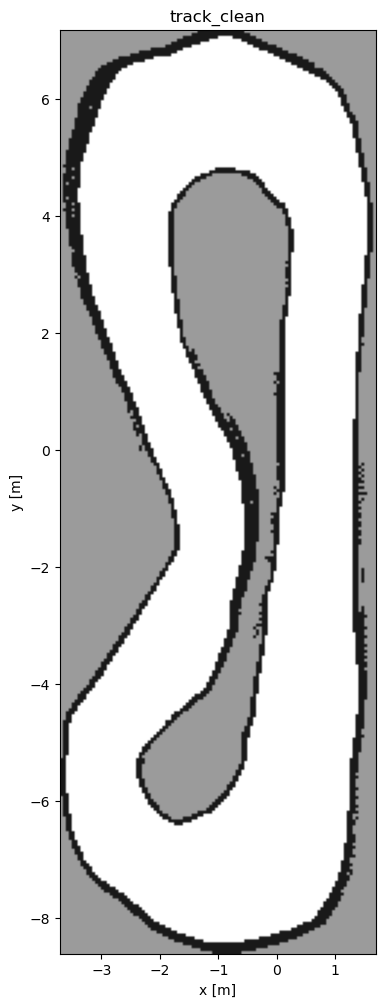

In [4]:
def show_map(ax):
    rgb = np.zeros((H, W, 3), np.uint8)
    rgb[WALL] = (25, 25, 25)
    rgb[FREE] = (255, 255, 255)
    rgb[UNKNOWN] = (155, 155, 155)
    ax.imshow(rgb, extent=EXTENT, origin="upper")
    ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
    return ax

fig, ax = plt.subplots(figsize=(5, 12))
show_map(ax); ax.set_title("track_clean")
plt.show()

## 2. Centerline

Skeletonize the driving surface: erode it to a 1-pixel-wide medial axis that
keeps the shape's topology. For a closed loop that gives a closed ring.

Skeletons normally sprout dead-end spurs, so prune by repeatedly deleting
endpoints (pixels with exactly one neighbour) until only cycles survive. On a
clean map this converges in zero iterations.

In [5]:
lab, n = ndimage.label(FREE)
sizes = ndimage.sum(FREE, lab, range(1, n + 1))
surface = lab == (int(np.argmax(sizes)) + 1)
print(f"driving surface: {surface.sum()} cells = {surface.sum()*res*res:.1f} m^2")

skel = skeletonize(surface)

K = np.ones((3, 3)); K[1, 1] = 0
neighbours = lambda m: ndimage.convolve(m.astype(np.uint8), K, mode="constant")

pruned = skel.copy()
for it in range(1000):
    ends = pruned & (neighbours(pruned) == 1)
    if not ends.any():
        break
    pruned[ends] = False
print(f"skeleton {skel.sum()} px -> pruned {pruned.sum()} px in {it} iterations")

llab, ln = ndimage.label(pruned, structure=np.ones((3, 3)))
lsz = ndimage.sum(pruned, llab, range(1, ln + 1))
loop = llab == (int(np.argmax(lsz)) + 1)
print(f"{ln} cycle(s); using the largest ({int(lsz.max())} px)")

driving surface: 18935 cells = 47.3 m^2
skeleton 589 px -> pruned 589 px in 0 iterations
1 cycle(s); using the largest (589 px)


In [6]:
# Walk the ring pixel by pixel to get them in order rather than raster order.
pts = np.argwhere(loop)
remaining = {tuple(p) for p in pts}
cur = tuple(pts[0])
order = [cur]; remaining.discard(cur)

while True:
    r, c = cur
    step = next((cand for dr in (-1, 0, 1) for dc in (-1, 0, 1)
                 if (dr or dc) and (cand := (r + dr, c + dc)) in remaining), None)
    if step is None:
        break
    order.append(step); remaining.discard(step); cur = step

print(f"ordered {len(order)} / {len(pts)} pixels", "OK" if not remaining else "-- GAP!")
raw = np.array([px2world(r, c) for r, c in order])
seg = np.linalg.norm(np.diff(np.vstack([raw, raw[:1]]), axis=0), axis=1)
print(f"raw loop length {seg.sum():.2f} m")

ordered 589 / 589 pixels OK
raw loop length 32.49 m


## 3. Smooth and resample

The pixel walk is staircased at 0.05 m. Fit a **periodic** spline (`per=True`
closes the loop seamlessly) and resample at uniform spacing. Derivatives of the
spline give heading and curvature for free.

In [7]:
tck, _ = interpolate.splprep([raw[:, 0], raw[:, 1]], s=SPLINE_SMOOTH, per=True)
u = np.linspace(0, 1, N_POINTS, endpoint=False)

cx, cy = interpolate.splev(u, tck)
dx, dy = interpolate.splev(u, tck, der=1)
ddx, ddy = interpolate.splev(u, tck, der=2)

psi = np.arctan2(dy, dx)                                    # heading [rad]
kappa = (dx * ddy - dy * ddx) / np.power(dx**2 + dy**2, 1.5)  # curvature [1/m]

seg = np.hypot(np.diff(np.append(cx, cx[0])), np.diff(np.append(cy, cy[0])))
s = np.concatenate([[0], np.cumsum(seg)[:-1]])

print(f"lap length {seg.sum():.2f} m over {N_POINTS} points ({seg.mean():.3f} m spacing)")
print(f"max |curvature| {np.abs(kappa).max():.2f} 1/m -> tightest radius {1/np.abs(kappa).max():.2f} m")

lap length 30.93 m over 400 points (0.077 m spacing)
max |curvature| 0.92 1/m -> tightest radius 1.09 m


## 4. Track widths

March outward along the centerline normal until leaving free space. Left and
right are measured separately -- the centerline sits mid-track, but the skeleton
is only exactly centred where the walls are locally parallel.

In [8]:
nx, ny = -np.sin(psi), np.cos(psi)   # unit left normal

def free_at(x, y):
    r, c = world2px(x, y)
    r, c = int(round(r)), int(round(c))
    return 0 <= r < H and 0 <= c < W and FREE[r, c]

def march(x, y, ux, uy, limit=3.0, step=res / 2):
    d = 0.0
    while d < limit:
        d += step
        if not free_at(x + ux * d, y + uy * d):
            return d - step
    return limit

w_left  = np.array([march(cx[i], cy[i],  nx[i],  ny[i]) for i in range(N_POINTS)])
w_right = np.array([march(cx[i], cy[i], -nx[i], -ny[i]) for i in range(N_POINTS)])
total = w_left + w_right

print(f"left  min {w_left.min():.2f}  median {np.median(w_left):.2f}  max {w_left.max():.2f}")
print(f"right min {w_right.min():.2f}  median {np.median(w_right):.2f}  max {w_right.max():.2f}")
print(f"total min {total.min():.2f}  median {np.median(total):.2f}  max {total.max():.2f}")
print(f"tightest gap leaves {total.min() - VEHICLE_WIDTH:.2f} m of slack for a {VEHICLE_WIDTH} m car")

left  min 0.50  median 0.70  max 1.32
right min 0.50  median 0.68  max 1.20
total min 1.03  median 1.40  max 2.52
tightest gap leaves 0.76 m of slack for a 0.27 m car


## 5. Check it visually

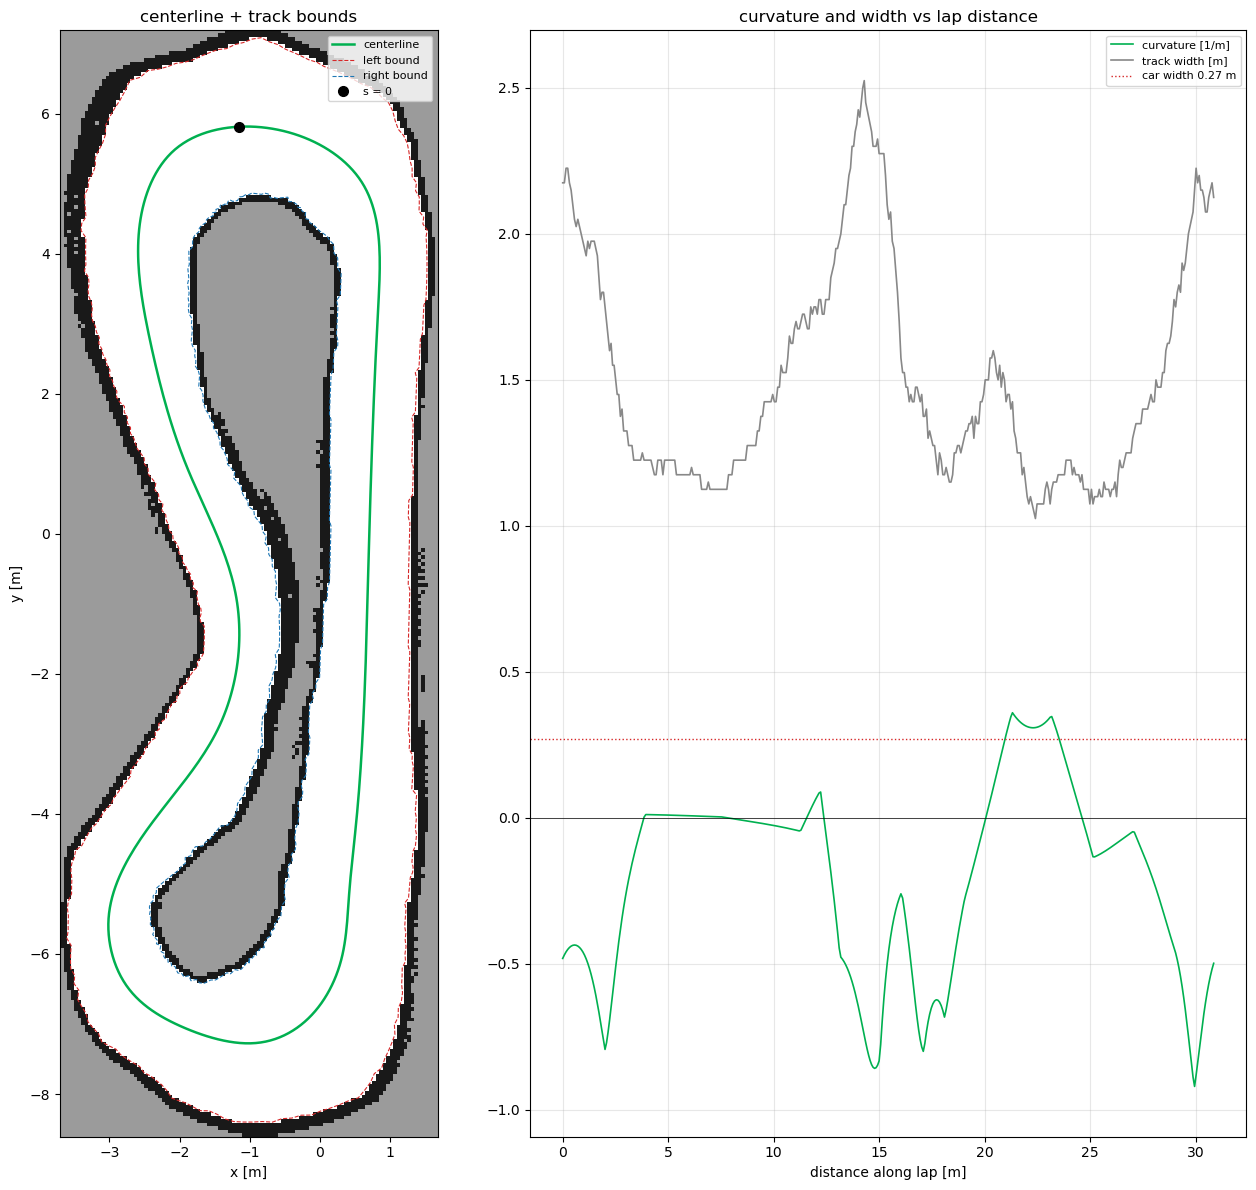

In [9]:
close = lambda a: np.append(a, a[0])

fig, axes = plt.subplots(1, 2, figsize=(13, 12),
                         gridspec_kw={"width_ratios": [1, 1.4]})

ax = show_map(axes[0])
ax.plot(close(cx), close(cy), "-", color="#00b050", lw=1.8, label="centerline")
ax.plot(close(cx + nx * w_left), close(cy + ny * w_left), "--", color="#d62728", lw=0.8, label="left bound")
ax.plot(close(cx - nx * w_right), close(cy - ny * w_right), "--", color="#1f77b4", lw=0.8, label="right bound")
ax.plot(cx[0], cy[0], "ko", ms=7, label="s = 0")
ax.legend(fontsize=8, loc="upper right")
ax.set_title("centerline + track bounds")

ax = axes[1]
ax.plot(s, kappa, color="#00b050", lw=1.2, label="curvature [1/m]")
ax.plot(s, total, color="#888", lw=1.2, label="track width [m]")
ax.axhline(VEHICLE_WIDTH, color="#d62728", ls=":", lw=1, label=f"car width {VEHICLE_WIDTH} m")
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("distance along lap [m]"); ax.legend(fontsize=8)
ax.set_title("curvature and width vs lap distance"); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 6. Export

Two files:

- `centerline_widths.csv` -- the 4-column input a raceline optimizer wants.
- `centerline_full.csv` -- adds `s`, `psi`, `kappa` for plotting and for a
  pure-pursuit follower that can run the centerline directly as a baseline.

Widths are shrunk by half the vehicle width so the optimizer's "stay in bounds"
constraint keeps the *car* inside the walls, not just its centre point.

In [10]:
margin = VEHICLE_WIDTH / 2
safe_l = np.maximum(w_left - margin, 0.0)
safe_r = np.maximum(w_right - margin, 0.0)

np.savetxt(OUT / "centerline_widths.csv",
           np.column_stack([cx, cy, safe_r, safe_l]),
           delimiter=",", fmt="%.4f",
           header="x_m,y_m,w_tr_right_m,w_tr_left_m", comments="# ")

np.savetxt(OUT / "centerline_full.csv",
           np.column_stack([s, cx, cy, psi, kappa, w_right, w_left]),
           delimiter=",", fmt="%.5f",
           header="s_m,x_m,y_m,psi_rad,kappa_radpm,w_right_m,w_left_m", comments="# ")

print("wrote", OUT / "centerline_widths.csv")
print("wrote", OUT / "centerline_full.csv")
print(f"\nusable corridor after {margin:.2f} m margin: "
      f"min {(safe_l+safe_r).min():.2f} m, median {np.median(safe_l+safe_r):.2f} m")

wrote /home/theflash/Documents/roboracer/raceline/centerline_widths.csv
wrote /home/theflash/Documents/roboracer/raceline/centerline_full.csv

usable corridor after 0.14 m margin: min 0.76 m, median 1.13 m


## Next

1. **Baseline** -- follow `centerline_full.csv` with pure pursuit. Slow but it
   proves the geometry and the follower before the optimizer is in the loop.
2. **Optimize** -- feed `centerline_widths.csv` to TUM's
   `global_racetrajectory_optimization` (minimum curvature) for a real raceline
   plus velocity profile. Needs `trajectory_planning_helpers`, `casadi`, `quadprog`.
3. **Compare** -- log the RL policy's driven path and overlay it here. If the
   policy is already faster than the optimized line, the line's speed profile is
   the thing to fix, not the geometry.
4. **Localize** -- none of this is raceable until pose comes from lidar + map
   instead of `/odom`, which is restricted at race time.